# **WindSpeed Dataset:**
#### 1.Data is Univariate [ Time + Wind Speed Measurement ]
#### 2.Discrete time index + Continous Values
#### 3.Stochastic
#### 4.One-step ahead Prediction
#### 5.Strong Short term & Stable parameter estimation
#### 6.Non-stationary

Imports

In [ ]:
pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 13.9 MB/s eta 0:00:00


In [ ]:
pip install pandas

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn statsmodels scikit-learn

In [ ]:

# Core numerical libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Time series models (linear)
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preprocessing
from sklearn.preprocessing import StandardScaler

# State-space / Kalman filtering
from pykalman import KalmanFilter



In [ ]:
pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=e35722a68005b93b2add745cc520652a9476ee9ad9c3dba4726e9231adb2f191
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


Data Loading and Preprocessing

Dataset shape: (5000,)
Index range: 0 to 4999
Missing values: 0


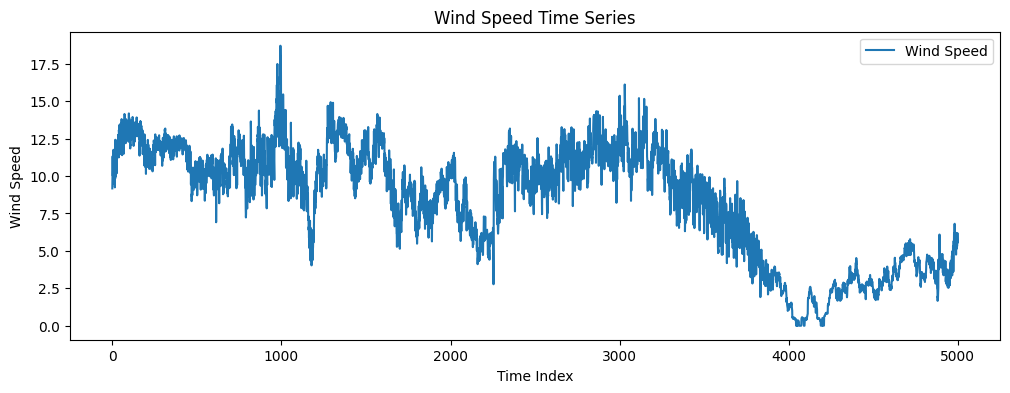

ADF Statistic: -2.029660262799446
p-value: 0.273721402942332
Series is non-stationary (fail to reject H0)
Training size: 4000
Validation size: 1000
Min value (train): 0.0
Max value (train): 1.0


In [ ]:
# ==============================

# Section 2: Data Loading & Preprocessing (Corrected)
# ==============================

# ---------
# 2.1 Load Dataset
# ---------
data_path = "WindSpeed.csv"

df = pd.read_csv(data_path)

# Assume first column is index, second is target
df.columns = ["Index", "WindSpeed"]

# Ensure correct ordering
df = df.sort_values(by="Index")

# Set index as time index
df.set_index("Index", inplace=True)

# Extract univariate series
series = df["WindSpeed"].astype(float)

print("Dataset shape:", series.shape)
print("Index range:", series.index.min(), "to", series.index.max())


# ---------
# 2.2 Missing Values Handling
# ---------
missing_count = series.isna().sum()
print("Missing values:", missing_count)

if missing_count > 0:
    series = series.interpolate(method="linear")


# ---------
# 2.3 Basic Visualization
# ---------
plt.figure(figsize=(12, 4))
plt.plot(series, label="Wind Speed")
plt.title("Wind Speed Time Series")
plt.xlabel("Time Index")
plt.ylabel("Wind Speed")
plt.legend()
plt.show()


# ---------
# 2.4 Stationarity Test (ADF)
# ---------
adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary (reject H0)")
else:
    print("Series is non-stationary (fail to reject H0)")


# ---------
# 2.5 Train / Validation Split (80% / 20%)
# ---------
train_size = int(len(series) * 0.8)

train_series = series.iloc[:train_size]
val_series = series.iloc[train_size:]

print("Training size:", len(train_series))
print("Validation size:", len(val_series))


# ---------
# 2.6 Min-Max Normalization (Used Only If Needed)
# ---------
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 1))

train_minmax = minmax_scaler.fit_transform(
    train_series.values.reshape(-1, 1)
).flatten()

val_minmax = minmax_scaler.transform(
    val_series.values.reshape(-1, 1)
).flatten()

# Update preprocessing container
preprocessed_data = {
    "series_raw": series,
    "train_series": train_series,
    "val_series": val_series,
    "train_minmax": train_minmax,
    "val_minmax": val_minmax,
    "scaler": minmax_scaler
}

print("Min value (train):", train_minmax.min())
print("Max value (train):", train_minmax.max())


In [ ]:
from scipy import stats
import numpy as np
import pandas as pd

def compute_dataset_statistics(series):
    """
    Computes key statistical measures for a given time series.

    Parameters:
    -----------
    series : pd.Series or np.array
        Input time series

    Returns:
    --------
    stats_dict : dict
        Dictionary of statistical measures
    """
    series_array = np.array(series)

    stats_dict = {}
    stats_dict['Count'] = len(series_array)
    stats_dict['Mean'] = np.mean(series_array)
    stats_dict['Median'] = np.median(series_array)

    # Safe mode calculation
    mode_res = stats.mode(series_array, nan_policy='omit', keepdims=True)
    # mode_res.mode may be a scalar or array, handle both
    if hasattr(mode_res.mode, "__len__"):
        mode_val = mode_res.mode[0]
    else:
        mode_val = mode_res.mode
    stats_dict['Mode'] = mode_val

    stats_dict['Min'] = np.min(series_array)
    stats_dict['Max'] = np.max(series_array)
    stats_dict['Range'] = stats_dict['Max'] - stats_dict['Min']
    stats_dict['Std Dev'] = np.std(series_array)
    stats_dict['Variance'] = np.var(series_array)
    stats_dict['Skewness'] = stats.skew(series_array)
    stats_dict['Kurtosis'] = stats.kurtosis(series_array)

    return stats_dict

# ------------------------------
# Compute statistics for the dataset
# ------------------------------
dataset_stats = compute_dataset_statistics(series)

# Convert to DataFrame for neat display
dataset_stats_df = pd.DataFrame(dataset_stats, index=[0])
print("Dataset Statistical Measures:")
print(dataset_stats_df.T)  # Transpose for better readability


Dataset Statistical Measures:
                    0
Count     5000.000000
Mean         8.393552
Median       9.550000
Mode         0.000000
Min          0.000000
Max         18.700000
Range       18.700000
Std Dev      3.734229
Variance    13.944466
Skewness    -0.535271
Kurtosis    -0.840337


#After Normalization

Normalized dataset saved to: WindSpeed_MinMax_Normalized.csv

Statistical Measures After Min-Max Normalization:
Mean: 0.4488530481283423
Standard Deviation: 0.19969138692921887
Variance: 0.03987665001371501
Minimum: 0.0
Maximum: 1.0
Median: 0.5106951871657754
Count: 5000
Skewness: -0.5352706080069213
Kurtosis: -0.8403373879134093


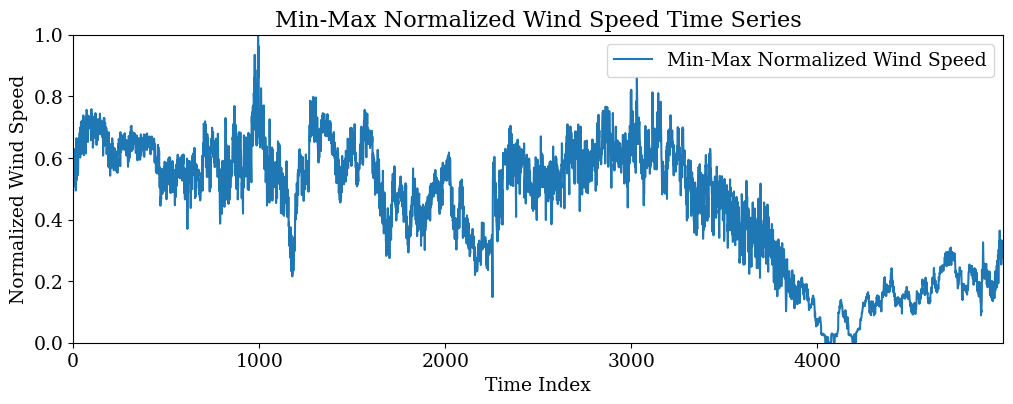

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---------
# Combine Train + Validation (RAW values, NOT normalized)
# ---------
full_series = np.concatenate([train_series, val_series])

# ---------
# Min-Max Normalization (GLOBAL)
# ---------
min_val_global = np.min(full_series)
max_val_global = np.max(full_series)

normalized_series = (full_series - min_val_global) / (max_val_global - min_val_global)

# ---------
# Save Normalized Data to CSV
# ---------
df_normalized = pd.DataFrame({
    "Index": series.index,
    "WindSpeed_MinMax": normalized_series
}).set_index("Index")

output_path = "WindSpeed_MinMax_Normalized.csv"
df_normalized.to_csv(output_path)

print("Normalized dataset saved to:", output_path)

# ---------
# Statistical Measures After Normalization
# ---------
mean_val = np.mean(normalized_series)
std_val = np.std(normalized_series, ddof=0)
var_val = np.var(normalized_series, ddof=0)
min_val = np.min(normalized_series)
max_val = np.max(normalized_series)
median_val = np.median(normalized_series)
count_val = normalized_series.size

skew_val = stats.skew(normalized_series)
kurtosis_val = stats.kurtosis(normalized_series)

print("\nStatistical Measures After Min-Max Normalization:")
print("Mean:", mean_val)
print("Standard Deviation:", std_val)
print("Variance:", var_val)
print("Minimum:", min_val)   # ✅ will be 0.0
print("Maximum:", max_val)   # ✅ will be 1.0
print("Median:", median_val)
print("Count:", count_val)
print("Skewness:", skew_val)
print("Kurtosis:", kurtosis_val)

# ---------
# Plot Normalized Time Series
# ---------
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Global LaTeX-like serif font
# -----------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
})

plt.figure(figsize=(12, 4))
plt.plot(
    df_normalized.index,
    df_normalized["WindSpeed_MinMax"],
    label="Min-Max Normalized Wind Speed"
)

plt.xlabel("Time Index")
plt.ylabel("Normalized Wind Speed")
plt.title("Min-Max Normalized Wind Speed Time Series")

plt.legend()
plt.grid(False)
plt.margins(False)

filename = "Min-Max Normalized Wind Speed Time Series.pdf"
plt.savefig(filename, format="pdf", bbox_inches="tight")
plt.show()



A. Linear Models [AR, MA, ARMA, ARIMA, Kalman Filter]

## One-step Ahead Forecasting with Re-fitting Each Step [Order 1]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Evaluation Results:
          Model      RMSE       MAE       MSE       MAPE(%)
0         AR(1)  0.012855  0.010282  0.000165  8.275533e+06
1         MA(1)  0.102300  0.080417  0.010465  1.121800e+08
2     ARMA(1,1)  0.011284  0.008595  0.000127  5.519722e+06
3  ARIMA(1,1,1)  0.012876  0.010203  0.000166  4.580181e+06
4     Kalman 1D  0.013407  0.010234  0.000180  4.228900e+06

AR(1)
-----
Actual vs Predicted


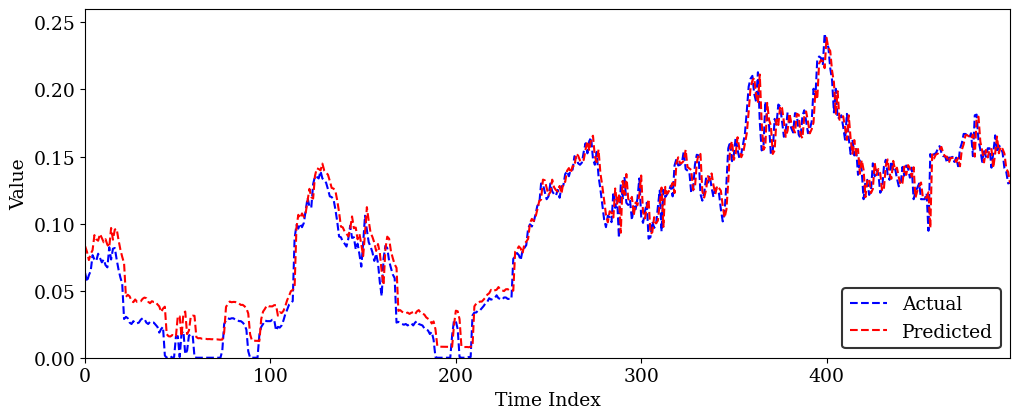

Prediction Error


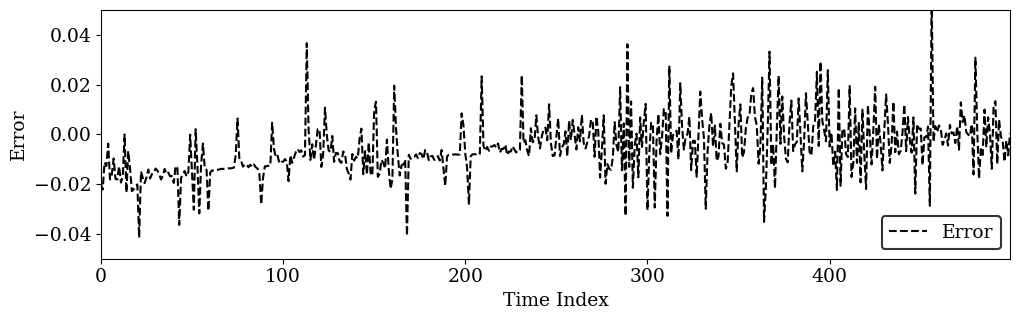


MA(1)
-----
Actual vs Predicted


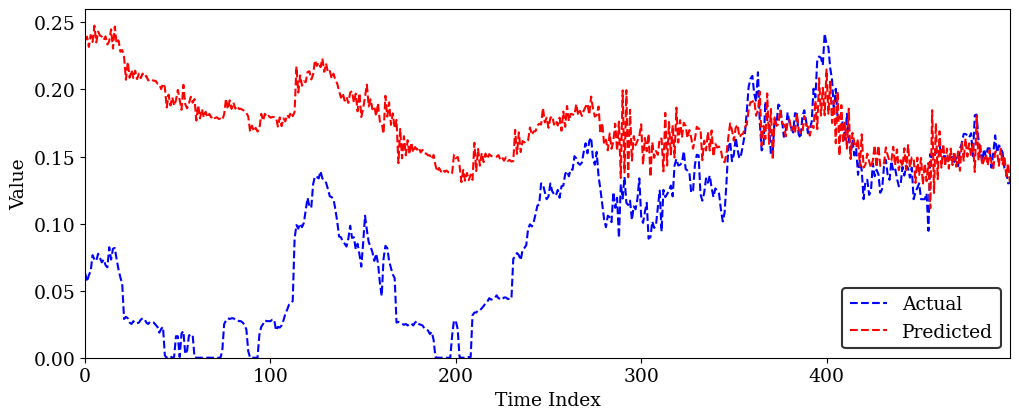

Prediction Error


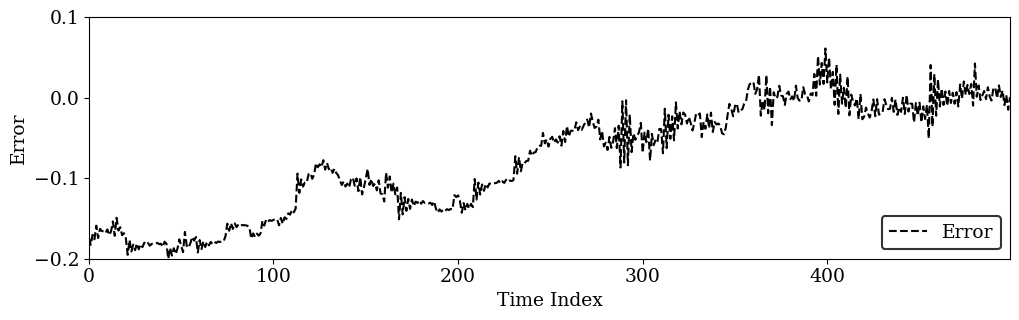


ARMA(1,1)
---------
Actual vs Predicted


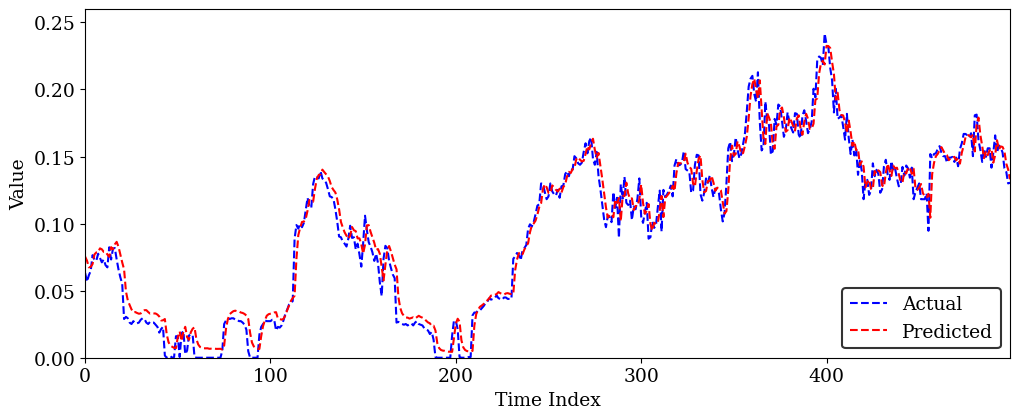

Prediction Error


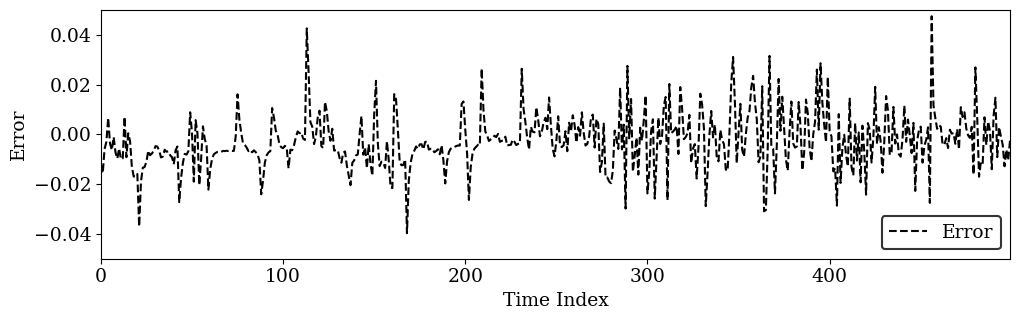


ARIMA(1,1,1)
------------
Actual vs Predicted


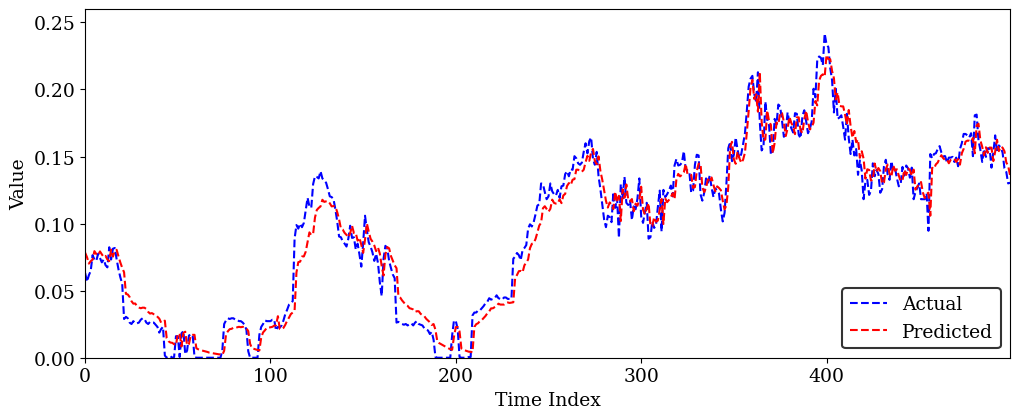

Prediction Error


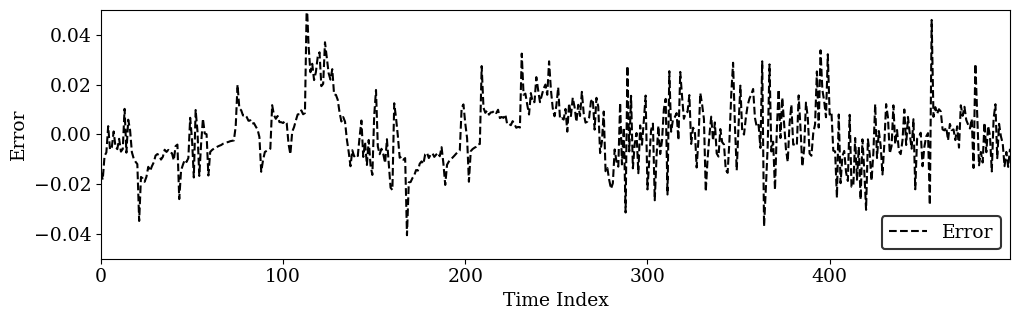


Kalman 1D
---------
Actual vs Predicted


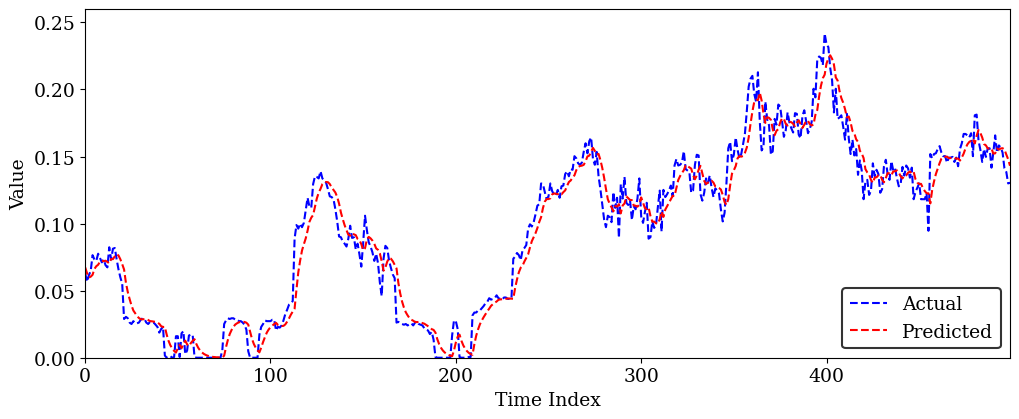

Prediction Error


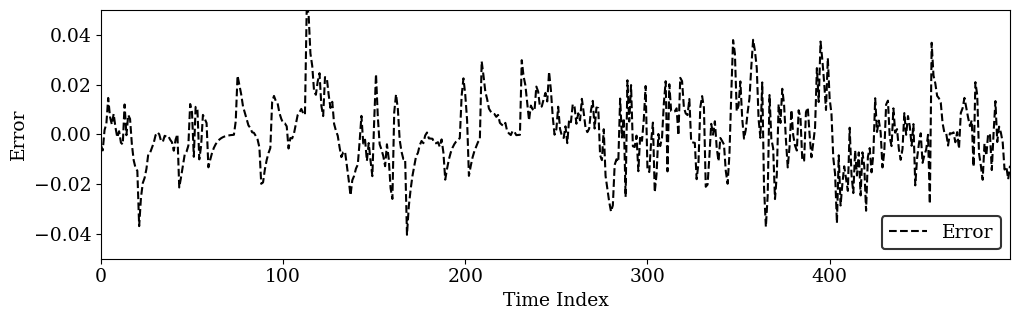

In [ ]:
# =====================================================
# LINEAR MODELS – ONE STEP AHEAD FORECASTING
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from filterpy.kalman import KalmanFilter

from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------------------------------
# Data Preparation (CSV-based, authoritative + 80/20 enforced)
# -----------------------------------------------------
df_norm = pd.read_csv("WindSpeed_MinMax_Normalized.csv")
df_norm = df_norm.sort_values(by="Index")  # keep same ordering assumption as Code 1

normalized_series = df_norm["WindSpeed_MinMax"].values.astype(float)

# Enforce 80/20 split
N = len(normalized_series)
n_train_expected = int(0.8 * N)
n_test_expected  = N - n_train_expected

y_train = normalized_series[:n_train_expected]
y_test  = normalized_series[n_train_expected:]   # unseen (test)

# Validation = first 500 points of test (or fewer if test < 500)
val_len = min(500, len(y_test))
y_val = y_test[:val_len]

# Sanity checks
assert len(y_train) == n_train_expected
assert len(y_test)  == n_test_expected
assert len(y_val)   == val_len
assert not np.isnan(normalized_series).any(), "NaNs in normalized_series"
assert not np.isnan(y_train).any(), "NaNs in y_train"
assert not np.isnan(y_val).any(), "NaNs in y_val"

# Optional: verify external variables match 80/20 if they exist
try:
    if len(train_minmax) != n_train_expected or len(val_minmax) != n_test_expected:
        print(
            "WARNING: train_minmax/val_minmax lengths do NOT match enforced 80/20 split.\n"
            f"Expected train={n_train_expected}, test={n_test_expected} based on CSV.\n"
            f"Found     train={len(train_minmax)}, test={len(val_minmax)} from train_minmax/val_minmax.\n"
            "This code will proceed using the CSV-enforced 80/20 split to ensure consistency."
        )
except NameError:
    pass

# -----------------------------------------------------
# Evaluation Metrics: RMSE, MAE, MSE, MAPE
# -----------------------------------------------------
def compute_metrics(y_true, y_pred, eps=1e-8):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    return rmse, mae, mse, mape

# -----------------------------------------------------
# One-Step-Ahead Forecasting (Rolling)
# -----------------------------------------------------
def rolling_forecast(model_func, y_train, y_val):
    window_size = 800
    history = list(y_train)
    preds = []

    for t in range(len(y_val)):
        model = model_func(history[-window_size:])
        yhat = model.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(y_val[t])

    return np.array(preds)

# -----------------------------------------------------
# Model Definitions
# -----------------------------------------------------
models = {
    "AR(1)": lambda hist: AutoReg(hist, lags=1).fit(),
    "MA(1)": lambda hist: ARIMA(hist, order=(0,0,1)).fit(),
    "ARMA(1,1)": lambda hist: ARIMA(hist, order=(1,0,1)).fit(),
    "ARIMA(1,1,1)": lambda hist: ARIMA(hist, order=(1,1,1)).fit()
}

results = {}

# -----------------------------------------------------
# Fit & Evaluate AR / MA / ARMA / ARIMA
# -----------------------------------------------------
for name, model_func in models.items():
    preds = rolling_forecast(model_func, y_train, y_val)
    metrics = compute_metrics(y_val, preds)
    results[name] = (preds, metrics)

# -----------------------------------------------------
# Kalman Filter (1D)
# -----------------------------------------------------
kf = KalmanFilter(dim_x=1, dim_z=1)
kf.x = np.array([[y_train[-1]]])
kf.F = np.array([[1]])
kf.H = np.array([[1]])
kf.P *= 1.0
kf.R *= 0.01
kf.Q *= 0.001

kalman_preds = []
for z in y_val:
    kf.predict()
    kalman_preds.append(kf.x[0, 0])
    kf.update(z)

kalman_preds = np.array(kalman_preds)
metrics = compute_metrics(y_val, kalman_preds)
results["Kalman 1D"] = (kalman_preds, metrics)

# -----------------------------------------------------
# Print Metrics (RMSE, MAE, MSE, MAPE)
# -----------------------------------------------------
metrics_table = []
for name, (_, m) in results.items():
    rmse_v, mae_v, mse_v, mape_v = m
    metrics_table.append([name, rmse_v, mae_v, mse_v, mape_v])

metrics_df = pd.DataFrame(
    metrics_table,
    columns=["Model", "RMSE", "MAE", "MSE", "MAPE(%)"]
)

print("\nEvaluation Results:")
print(metrics_df)

# -----------------------------------------------------
# PLOTTING
# -----------------------------------------------------
colors = {
    "Actual": "blue",
    "Predicted": "red",
    "Error": "black"
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
})

manual_scale = {
    "Actual_vs_Predicted": (0.00, 0.26),
    "Error": (-0.2, 0.1)
}

assert "results" in globals() and isinstance(results, dict) and len(results) > 0, \
    "results dict not found or empty. Run the forecasting code cell first."
assert "y_val" in globals(), "y_val not found. Run the data preparation/forecasting cell first."

for name, (preds, _) in results.items():
    error = y_val - preds
    x = np.arange(len(y_val))

    print(f"\n{name}")
    print("-" * len(name))
    print("Actual vs Predicted")

    # -------------------------
    # Actual vs Predicted
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, y_val, label="Actual", color=colors["Actual"], linestyle="--", linewidth=1.5)
    ax.plot(x, preds, label="Predicted", color=colors["Predicted"], linestyle="--", linewidth=1.5)

    ax.set_xlim([0, len(y_val) - 1])
    ax.set_ylim(manual_scale["Actual_vs_Predicted"])

    ax.set_xlabel("Time Index")
    ax.set_ylabel("Value")

    legend = ax.legend(loc="lower right")
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout(pad=0)
    plt.savefig(f"{name}_actual_vs_predicted.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    print("Prediction Error")

    # -------------------------
    # Prediction Error
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(x, error, label="Error", color=colors["Error"], linestyle="--", linewidth=1.5)

    ax.set_xlim([0, len(error) - 1])

    # Adjust error scale except for MA plot
    if name != "MA(1)":
        ax.set_ylim([-0.05, 0.05])
    else:
        ax.set_ylim(manual_scale["Error"])

    ax.set_xlabel("Time Index")
    ax.set_ylabel("Error")

    legend = ax.legend(loc="lower right")
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout(pad=0)
    plt.savefig(f"{name}_prediction_error.pdf", format="pdf", bbox_inches="tight")
    plt.show()


#Variations of ARIMA Family Models
##{1,2,3,4,5} AR & MA
##{(1,1),(1,2),(2,1),(2,2),(5,5)} ARMA
##{(1,1,1),(1,1,2),(1,2,1),(2,1,1),(5,1,5)} ARIMA

###- Order Selection for p,q is max 5
###- Order Selection for d is 1,2



#Variations till 5

AR(1)          RMSE=0.012855 | MAE=0.010282 | MSE=0.000165 | MAPE=8275532.908%
AR(2)          RMSE=0.011885 | MAE=0.009389 | MSE=0.000141 | MAPE=6879868.419%
AR(3)          RMSE=0.011334 | MAE=0.008700 | MSE=0.000128 | MAPE=5824339.925%
AR(4)          RMSE=0.011100 | MAE=0.008375 | MSE=0.000123 | MAPE=5135095.890%
AR(5)          RMSE=0.011175 | MAE=0.008329 | MSE=0.000125 | MAPE=4856259.006%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

MA(1)          RMSE=0.102300 | MAE=0.080417 | MSE=0.010465 | MAPE=112180017.610%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

MA(2)          RMSE=0.068992 | MAE=0.054489 | MSE=0.004760 | MAPE=74307972.653%


...

ARIMA(1,2,1)   RMSE=0.010442 | MAE=0.007063 | MSE=0.000109 | MAPE=865064.523%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Like

ARIMA(2,1,1)   RMSE=0.012936 | MAE=0.010161 | MSE=0.000167 | MAPE=4453270.321%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conver

ARIMA(5,1,5)   RMSE=0.012944 | MAE=0.010232 | MSE=0.000168 | MAPE=4576823.959%

Metrics Summary (sorted by RMSE):
       Model     RMSE      MAE      MSE      MAPE(%)
ARIMA(1,2,1) 0.010442 0.007063 0.000109 8.650645e+05
       AR(4) 0.011100 0.008375 0.000123 5.135096e+06
       AR(5) 0.011175 0.008329 0.000125 4.856259e+06
   ARMA(1,1) 0.011284 0.008595 0.000127 5.519722e+06
       AR(3) 0.011334 0.008700 0.000128 5.824340e+06
       AR(2) 0.011885 0.009389 0.000141 6.879868e+06
   ARMA(1,2) 0.012131 0.009287 0.000147 5.045068e+06
   ARMA(5,5) 0.012164 0.009533 0.000148 6.715748e+06
       AR(1) 0.012855 0.010282 0.000165 8.275533e+06
ARIMA(1,1,1) 0.012876 0.010203 0.000166 4.580181e+06
   ARMA(2,2) 0.012890 0.010169 0.000166 6.566891e+06
ARIMA(2,1,1) 0.012936 0.010161 0.000167 4.453270e+06
ARIMA(5,1,5) 0.012944 0.010232 0.000168 4.576824e+06
ARIMA(1,1,2) 0.013028 0.010302 0.000170 4.481539e+06
   ARMA(2,1) 0.013481 0.010476 0.000182 6.809943e+06
       MA(5) 0.039242 0.031466 0.00154

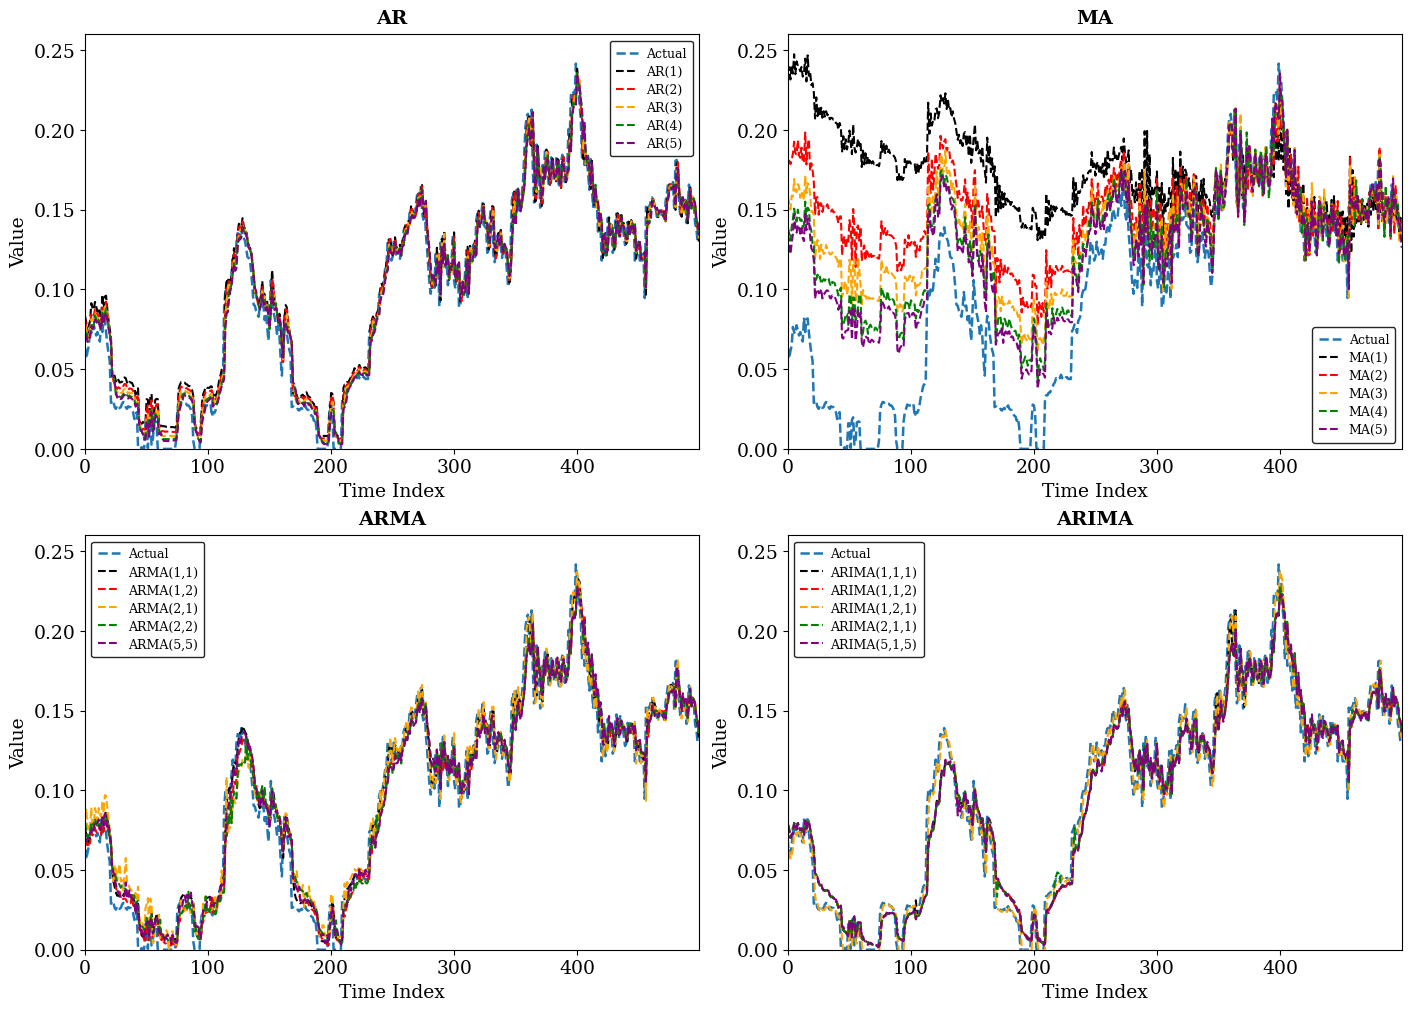

In [ ]:
# =====================================================
# LINEAR MODELS – ONE STEP AHEAD FORECASTING (ARIMA family variations)
# + grouped plotting: 4 subplots (AR / MA / ARMA / ARIMA), each overlays 5 orders
# + metrics: RMSE, MAE, MSE, MAPE
# + legend fitted to available space
# =====================================================

import numpy as np
import pandas as pd

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------------------------------
# Data Preparation (CSV-based, authoritative + 80/20 enforced)
# -----------------------------------------------------
df_norm = pd.read_csv("WindSpeed_MinMax_Normalized.csv")
df_norm = df_norm.sort_values(by="Index")

normalized_series = df_norm["WindSpeed_MinMax"].values.astype(float)

N = len(normalized_series)
n_train_expected = int(0.8 * N)
n_test_expected  = N - n_train_expected

y_train = normalized_series[:n_train_expected]
y_test  = normalized_series[n_train_expected:]

val_len = min(500, len(y_test))
y_val = y_test[:val_len]

assert len(y_train) == n_train_expected
assert len(y_test)  == n_test_expected
assert len(y_val)   == val_len
assert not np.isnan(normalized_series).any(), "NaNs in normalized_series"
assert not np.isnan(y_train).any(), "NaNs in y_train"
assert not np.isnan(y_val).any(), "NaNs in y_val"

try:
    if len(train_minmax) != n_train_expected or len(val_minmax) != n_test_expected:
        print(
            "WARNING: train_minmax/val_minmax lengths do NOT match enforced 80/20 split.\n"
            f"Expected train={n_train_expected}, test={n_test_expected} based on CSV.\n"
            f"Found     train={len(train_minmax)}, test={len(val_minmax)} from train_minmax/val_minmax.\n"
            "This code will proceed using the CSV-enforced 80/20 split to ensure consistency."
        )
except NameError:
    pass

# -----------------------------------------------------
# Metrics: RMSE, MAE, MSE, MAPE
# -----------------------------------------------------
def compute_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    return rmse, mae, mse, mape

# -----------------------------------------------------
# One-Step-Ahead Forecasting (Rolling)
# -----------------------------------------------------
def rolling_forecast(model_func, y_train, y_val, window_size=800):
    history = list(y_train)
    preds = []

    for t in range(len(y_val)):
        hist_window = history[-window_size:] if len(history) >= window_size else history
        model = model_func(hist_window)
        yhat = model.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(y_val[t])  # walk-forward: use true observed

    return np.array(preds)

# -----------------------------------------------------
# Model Definitions (variations + order 5)
# -----------------------------------------------------
models = {}

for p in [1, 2, 3, 4, 5]:
    models[f"AR({p})"] = lambda hist, p=p: AutoReg(hist, lags=p).fit()

for q in [1, 2, 3, 4, 5]:
    models[f"MA({q})"] = lambda hist, q=q: ARIMA(hist, order=(0, 0, q)).fit()

for p, q in [(1, 1), (1, 2), (2, 1), (2, 2), (5, 5)]:
    models[f"ARMA({p},{q})"] = lambda hist, p=p, q=q: ARIMA(hist, order=(p, 0, q)).fit()

for p, d, q in [(1, 1, 1), (1, 1, 2), (1, 2, 1), (2, 1, 1), (5, 1, 5)]:
    models[f"ARIMA({p},{d},{q})"] = lambda hist, p=p, d=d, q=q: ARIMA(hist, order=(p, d, q)).fit()

# -----------------------------------------------------
# Fit & Evaluate (Rolling) + STORE predictions for plotting
# -----------------------------------------------------
metric_rows = []
results = {}  # store preds + metrics

for name, model_func in models.items():
    try:
        preds = rolling_forecast(model_func, y_train, y_val, window_size=800)
        rmse_v, mae_v, mse_v, mape_v = compute_metrics(y_val, preds)

        metric_rows.append([name, rmse_v, mae_v, mse_v, mape_v])
        results[name] = (preds, (rmse_v, mae_v, mse_v, mape_v))

        print(f"{name:14s} RMSE={rmse_v:.6f} | MAE={mae_v:.6f} | MSE={mse_v:.6f} | MAPE={mape_v:.3f}%")
    except Exception as e:
        metric_rows.append([name, np.nan, np.nan, np.nan, np.nan])
        print(f"{name:14s} FAILED ({type(e).__name__}: {e})")

assert len(results) > 0, "No stored results found; plotting will not work."

metrics_df = pd.DataFrame(
    metric_rows,
    columns=["Model", "RMSE", "MAE", "MSE", "MAPE(%)"]
).sort_values("RMSE")

print("\nMetrics Summary (sorted by RMSE):")
print(metrics_df.to_string(index=False))

# =====================================================
# GROUPED PLOTTING: 1 figure, 4 subplots (2x2)
# Each overlays Actual + 5 variations
# Legend is fitted to subplot space (compact + wrapped)
# =====================================================

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black"
})


manual_scale = {
    "Actual_vs_Predicted": (0.00, 0.26),
}

x = np.arange(len(y_val))

groups = {
    "AR":    [f"AR({p})" for p in [1, 2, 3, 4, 5]],
    "MA":    [f"MA({q})" for q in [1, 2, 3, 4, 5]],
    "ARMA":  [f"ARMA({p},{q})" for p, q in [(1, 1), (1, 2), (2, 1), (2, 2), (5, 5)]],
    "ARIMA": [f"ARIMA({p},{d},{q})" for p, d, q in [(1, 1, 1), (1, 1, 2), (1, 2, 1), (2, 1, 1), (5, 1, 5)]],
}

variant_colors = ["black", "red", "orange", "green", "purple"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

for idx, (family_name, model_names) in enumerate(groups.items()):
    ax = axes[idx]

    missing = [m for m in model_names if m not in results]
    if missing:
        ax.set_title(f"{family_name} (missing runs)")
        ax.axis("off")
        continue

    # Actual
    ax.plot(x, y_val, label="Actual", linestyle="--", linewidth=1.8)

    # Variations
    for i, mname in enumerate(model_names):
        preds = results[mname][0]
        ax.plot(
            x, preds,
            label=mname,
            color=variant_colors[i % len(variant_colors)],
            linestyle="--",
            linewidth=1.5
        )

    ax.set_xlim([0, len(y_val) - 1])
    ax.set_ylim(manual_scale["Actual_vs_Predicted"])
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Value")
    ax.set_title(family_name, fontsize=14, fontweight="bold", pad=8)

    # --- Legend fitted to available subplot space ---
    # 2 columns makes it compact; smaller fontsize; tighter paddings
    legend = ax.legend(

        loc="best",                 # auto avoid overlap
        ncol=1,
        fontsize=9,
        framealpha=0.85,
        labelspacing=0.4,
        handlelength=1.8,
        handletextpad=0.6,
        borderpad=0.5,
        columnspacing=1.0
        )

    legend.get_frame().set_linewidth(1.0)


# Save exactly once (not inside loop)
plt.savefig("All_Models_Comparison.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()


#B. Nonlinear Models [ NAR, FAR, TAR ]

#One-step Ahead Forecasting With Refitting Each Step


Evaluation Results (Nonlinear Models):
              Model       MSE      RMSE       SSE
0  NAR (Polynomial)  0.000144  0.011986  0.071838
1               TAR  0.000173  0.013159  0.086586
2               FAR  0.000115  0.010731  0.057578

NAR (Polynomial)
----------------
Actual vs Predicted


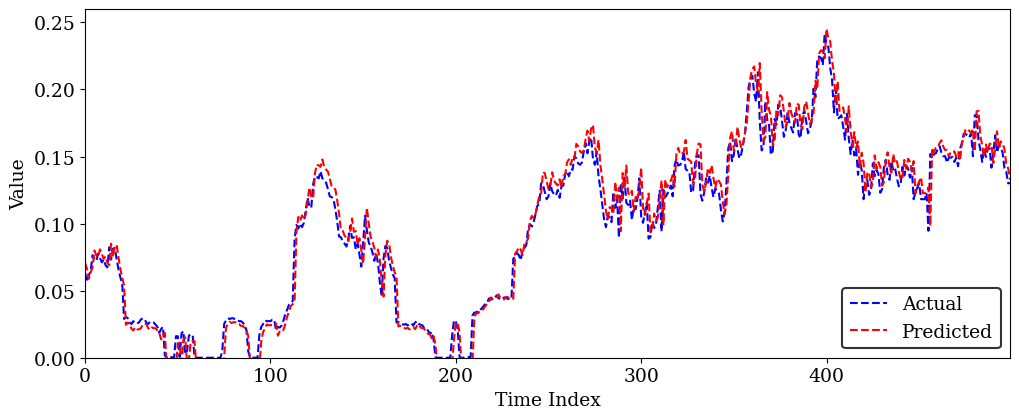

Prediction Error


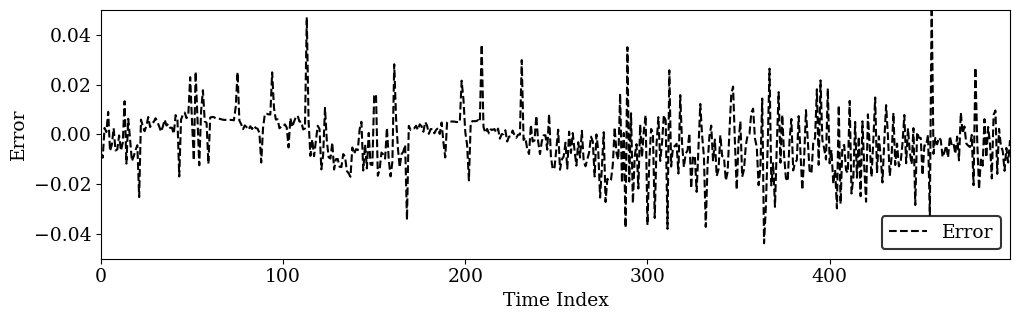


TAR
---
Actual vs Predicted


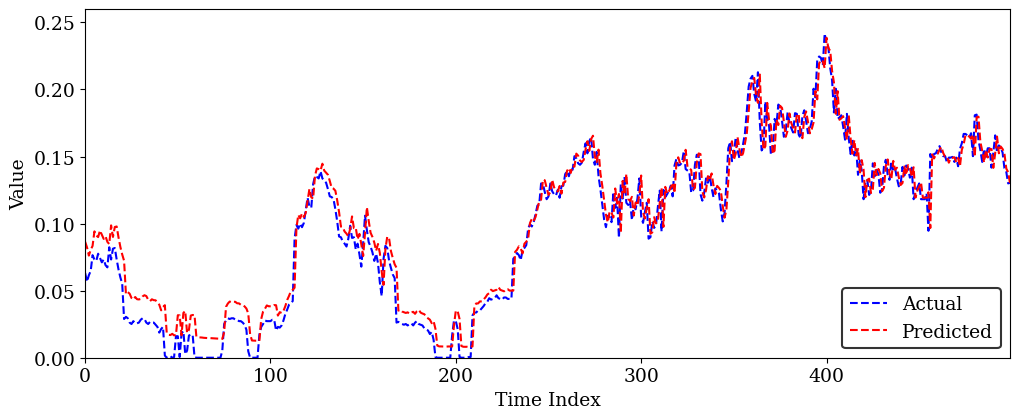

Prediction Error


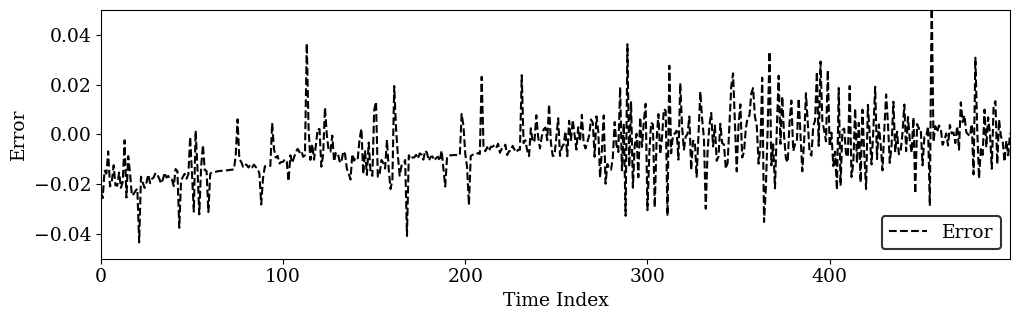


FAR
---
Actual vs Predicted


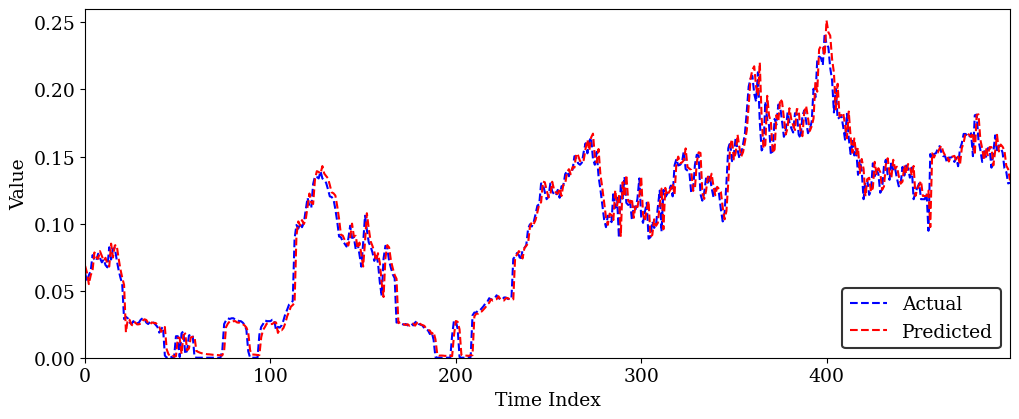

Prediction Error


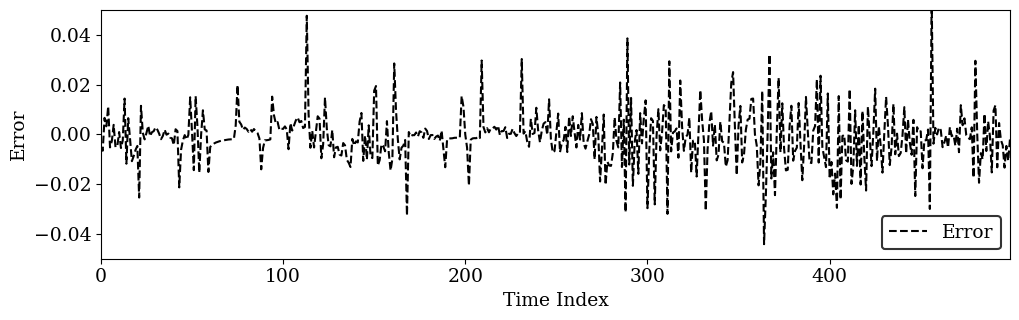

In [ ]:
# =====================================================
# NONLINEAR MODELS – ONE STEP AHEAD FORECASTING
# =====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from statsmodels.tsa.ar_model import AutoReg

# -----------------------------------------------------
# Data Preparation (CSV-based, authoritative + 80/20 enforced)
# -----------------------------------------------------
import numpy as np
import pandas as pd

# 1) Load normalized data from CSV (single source of truth)
df_norm = pd.read_csv("WindSpeed_MinMax_Normalized.csv")
df_norm = df_norm.sort_values(by="Index")  # keep same ordering assumption as Code 1

normalized_series = df_norm["WindSpeed_MinMax"].values.astype(float)

# 2) Enforce 80/20 split from the actual series length
N = len(normalized_series)
n_train_expected = int(0.8 * N)
n_test_expected  = N - n_train_expected

y_train = normalized_series[:n_train_expected]
y_test  = normalized_series[n_train_expected:]   # this is the unseen part (test)

# 3) Validation = first 500 points of test (or fewer if test < 500)
val_len = min(500, len(y_test))
y_val = y_test[:val_len]

# 4) Sanity checks
assert len(y_train) == n_train_expected
assert len(y_test)  == n_test_expected
assert len(y_val)   == val_len
assert not np.isnan(normalized_series).any(), "NaNs in normalized_series"
assert not np.isnan(y_train).any(), "NaNs in y_train"
assert not np.isnan(y_val).any(), "NaNs in y_val"

# 5) Optional: verify external variables match 80/20 if they exist
try:
    if len(train_minmax) != n_train_expected or len(val_minmax) != n_test_expected:
        print(
            "WARNING: train_minmax/val_minmax lengths do NOT match enforced 80/20 split.\n"
            f"Expected train={n_train_expected}, test={n_test_expected} based on CSV.\n"
            f"Found     train={len(train_minmax)}, test={len(val_minmax)} from train_minmax/val_minmax.\n"
            "This code will proceed using the CSV-enforced 80/20 split to ensure consistency."
        )
except NameError:
    # train_minmax / val_minmax not defined in this script, fine.
    pass


# -----------------------------------------------------
# Evaluation Metrics
# -----------------------------------------------------
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    sse = np.sum((y_true - y_pred) ** 2)
    return mse, rmse, sse

# =====================================================
# NAR – NONLINEAR AUTOREGRESSIVE (POLYNOMIAL)
# =====================================================
def rolling_forecast_nar(y_train, y_val, lags=1, degree=2):
    history = list(y_train)
    preds = []

    poly = PolynomialFeatures(degree=degree, include_bias=True)
    model = LinearRegression()

    for t in range(len(y_val)):
        hist_window = np.array(history[-800:])

        # --- one-line guard ---
        if len(hist_window) <= lags:
            preds.append(hist_window[-1])
            history.append(y_val[t])
            continue
        # ----------------------

        X, y = [], []
        for i in range(lags, len(hist_window)):
            X.append(hist_window[i-lags:i])
            y.append(hist_window[i])

        X = poly.fit_transform(np.array(X))
        y = np.array(y)

        model.fit(X, y)

        x_input = poly.transform([hist_window[-lags:]])
        preds.append(model.predict(x_input)[0])

        history.append(y_val[t])


    return np.array(preds)

# =====================================================
# TAR – TRUE THRESHOLD AUTOREGRESSIVE
# =====================================================
def rolling_forecast_tar(y_train, y_val, lag=1):
    history = list(y_train)
    preds = []

    threshold = np.median(y_train)

    for t in range(len(y_val)):
        hist_window = np.array(history[-800:])

        # Regime separation
        low_regime  = hist_window[hist_window <= threshold]
        high_regime = hist_window[hist_window > threshold]

        # Fallback if one regime is too small
        if len(low_regime) <= lag or len(high_regime) <= lag:
            # If a regime is too small, use a simple AR model on the whole window
            model = AutoReg(hist_window, lags=lag).fit()
        else:
            # Use appropriate regime model based on the last observed value
            if history[-1] <= threshold:
                model = AutoReg(low_regime, lags=lag).fit()
            else:
                model = AutoReg(high_regime, lags=lag).fit()

        preds.append(model.forecast(1)[0])
        history.append(y_val[t])

    return np.array(preds)

# =====================================================
# FAR – FUNCTIONAL COEFFICIENT AUTOREGRESSIVE
# =====================================================
def rolling_forecast_far(y_train, y_val):
    history = list(y_train)
    preds = []

    for t in range(len(y_val)):
        hist_window = np.array(history[-800:])

        X = hist_window[:-1].reshape(-1, 1)
        y = hist_window[1:]

        model = KernelRidge(
            kernel="rbf",
            alpha=1e-11,
            gamma=2
        )
        model.fit(X, y)

        preds.append(model.predict([[history[-1]]])[0])
        history.append(y_val[t])

    return np.array(preds)

# =====================================================
# FIT & EVALUATE NONLINEAR MODELS
# =====================================================
results = {}

nar_preds = rolling_forecast_nar(y_train, y_val)
results["NAR (Polynomial)"] = (nar_preds, compute_metrics(y_val, nar_preds))

tar_preds = rolling_forecast_tar(y_train, y_val)
results["TAR"] = (tar_preds, compute_metrics(y_val, tar_preds))

far_preds = rolling_forecast_far(y_train, y_val)
results["FAR"] = (far_preds, compute_metrics(y_val, far_preds))

# =====================================================
# METRICS TABLE
# =====================================================
metrics_table = []

for name, (_, m) in results.items():
    metrics_table.append([name, *m])

metrics_df = pd.DataFrame(
    metrics_table,
    columns=["Model", "MSE", "RMSE", "SSE"]
)

print("\nEvaluation Results (Nonlinear Models):")
print(metrics_df)




#######PLOTTING############

import matplotlib.pyplot as plt
import numpy as np

# Dark color palette
colors = {
    "Actual": "blue",
    "Predicted": "red",
    "Error": "black"
}

# Set global plot style for LaTeX-like serif font
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
})

# Manual y-axis scale
manual_scale = {
    "Actual_vs_Predicted": (0.00, 0.26),
    "Error": (-0.05, 0.05)
}

# Optional safety checks to ensure this cell uses predictions created above
assert "results" in globals() and isinstance(results, dict) and len(results) > 0, \
    "results dict not found or empty. Run the forecasting code cell first."
assert "y_val" in globals(), "y_val not found. Run the data preparation/forecasting cell first."

for name, (preds, _) in results.items():
    error = y_val - preds
    x = np.arange(len(y_val))

    # =====================================
    # TEXT TITLES (printed, not in figures)
    # =====================================
    print(f"\n{name}")
    print("-" * len(name))
    print("Actual vs Predicted")

    # -----------------------------------------------------
    # Actual vs Predicted (NO title inside plot)
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, y_val, label="Actual", color=colors["Actual"], linestyle="--", linewidth=1.5)
    ax.plot(x, preds, label="Predicted", color=colors["Predicted"], linestyle="--", linewidth=1.5)

    ax.set_xlim([0, len(y_val) - 1])
    ax.set_ylim(manual_scale["Actual_vs_Predicted"])

    # Axis labels (consistent with rcParams font)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Value")

    # Legend bottom-right
    legend = ax.legend(loc="lower right")
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout(pad=0)
    plt.savefig(f"{name}_actual_vs_predicted.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # -------------------------------------
    # Print label for the second plot
    # -------------------------------------
    print("Prediction Error")

    # -----------------------------------------------------
    # Prediction Error (NO title inside plot)
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(x, error, label="Error", color=colors["Error"], linestyle="--", linewidth=1.5)

    ax.set_xlim([0, len(error) - 1])
    ax.set_ylim(manual_scale["Error"])

    # Axis labels (consistent with rcParams font)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Error")

    # Legend bottom-right
    legend = ax.legend(loc="lower right")
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout(pad=0)
    plt.savefig(f"{name}_prediction_error.pdf", format="pdf", bbox_inches="tight")
    plt.show()
